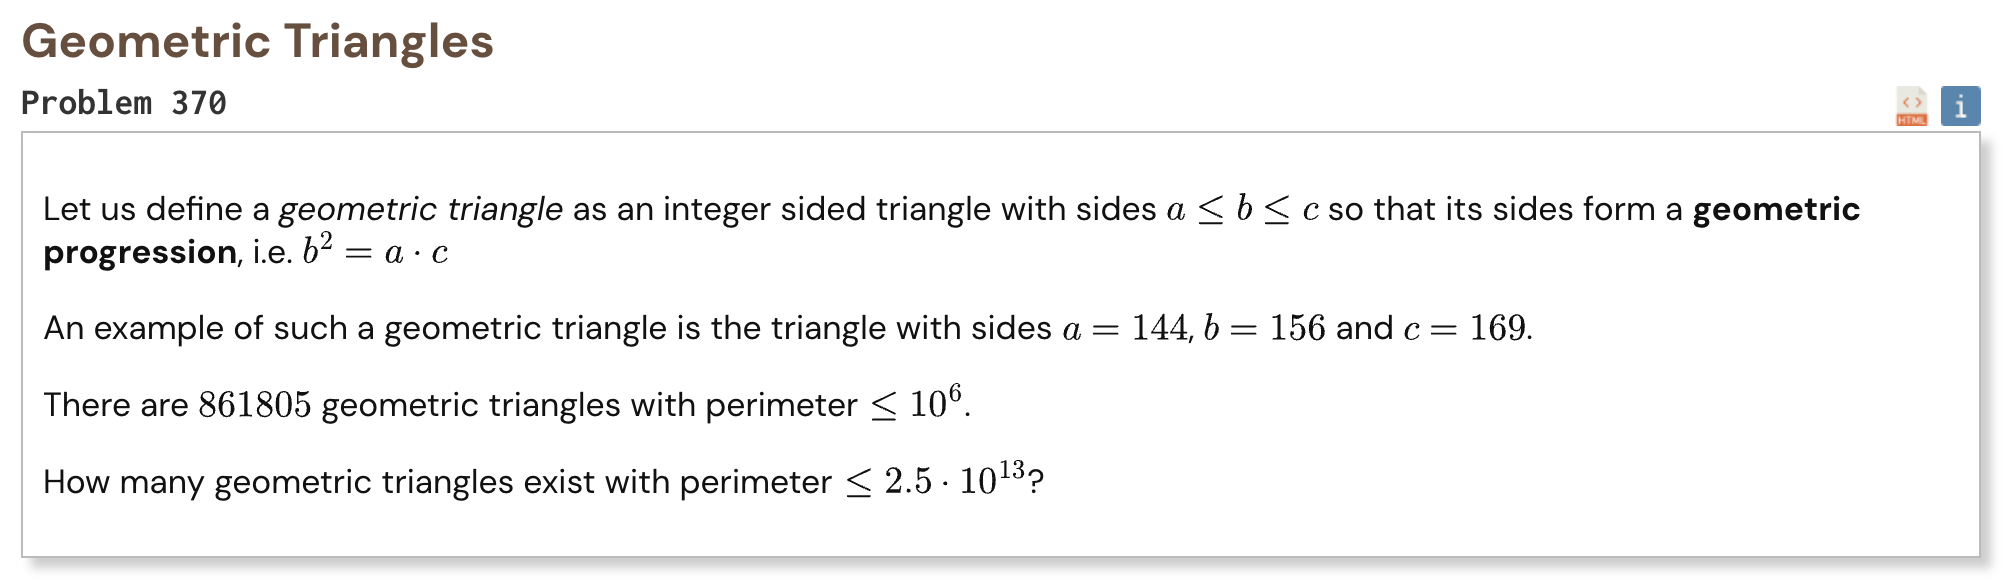

## Initial approach

* generate primitive triangle bases from two coprime parameters
* include the equilateral case naturally
* for each fixed lower parameter, count valid upper parameters by ranges
* use mobius inclusion-exclusion to count coprime values in a whole interval
* group intervals where the perimeter quotient stays the same
* this removes the slow direct gcd loop
* print the same final result much faster

In [1]:
import math

def linear_sieve_spf(limit):
    spf = [0] * (limit + 1)
    primes = []

    if limit >= 1:
        spf[1] = 1

    for i in range(2, limit + 1):
        if spf[i] == 0:
            spf[i] = i
            primes.append(i)

        for p in primes:
            value = i * p

            if value > limit:
                break

            spf[value] = p

            if p == spf[i]:
                break

    return spf

def squarefree_divisors_with_mu(n, spf):
    primes = []
    x = n

    while x > 1:
        p = spf[x]
        primes.append(p)

        while x % p == 0:
            x //= p

    divs = [1]
    mus = [1]

    for p in primes:
        size = len(divs)

        for i in range(size):
            divs.append(divs[i] * p)
            mus.append(-mus[i])

    return divs, mus

def count_coprime_in_range(left, right, divs, mus):
    if right < left:
        return 0

    total = 0
    before = left - 1

    for d, mu in zip(divs, mus):
        total += mu * (right // d - before // d)

    return total

def m_limit_by_ratio(n):
    return (n + math.isqrt(5 * n * n - 1)) // 2

def m_limit_by_perimeter(n, limit):
    disc = 4 * limit - 3 * n * n

    if disc < 0:
        return -1

    return (math.isqrt(disc) - n) // 2

def count_geometric_triangles(limit):
    n_max = math.isqrt(limit // 3)
    spf = linear_sieve_spf(n_max)

    total = 0

    for n in range(1, n_max + 1):
        m_max = min(m_limit_by_ratio(n), m_limit_by_perimeter(n, limit))

        if m_max < n:
            continue

        divs, mus = squarefree_divisors_with_mu(n, spf)

        m = n

        while m <= m_max:
            q = limit // (m * m + m * n + n * n)
            high_value = limit // q
            disc = 4 * high_value - 3 * n * n
            m_end = (math.isqrt(disc) - n) // 2

            if m_end > m_max:
                m_end = m_max

            coprime_count = count_coprime_in_range(m, m_end, divs, mus)
            total += q * coprime_count

            m = m_end + 1

    return total

assert count_geometric_triangles(10 ** 6) == 861805

In [2]:
%%time
result = count_geometric_triangles(25_000_000_000_000)
print("Result:", result)

Result: 41791929448408
CPU times: user 7min 3s, sys: 1.96 s, total: 7min 5s
Wall time: 7min 6s
